***END TO END DATA ANALYTICS PROJECT USING PYTHON***

## AGENDA: Perform complete data analytics project life cycle using python
1. Basics of Python
2. Pandas
3. Matplotlib
4. Seaborn


## What is Data Analysis?

Raw data is processed and transformed into meaningful insights that can be extracted and organized for business use. When this information supports decision-making and benefits an organization, it is known as Data Analytics or Data Analysis, ultimately contributing to the company’s growth.

Raw Data - Transform - Useful information(is able to extract) - Organization.

Types of Data Analysis:
1. Uni-Variate: 1-column
2. Bi-Variate: 2-column
3. Multi-Variate: more than 2 column

Raw Data:

Steps:-
1. Reading data
2. Understanding data - No. of.columns, No. of.rows, Null values, Duplicates

Observations:-
1. reviews - float(to change int) - int
2. Purchased last month - float(to change int) - int
3. Delivery date - object(to cahnge date format) - date

remove more than 45%
4. drop(null valu) sustainability column

Measure of central Tendency

Centre: Mean, Median, Mode

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"/content/amazon_products_sales_data_cleaned.csv")
df.head(2)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [ ]:
len(df)

42675

In [ ]:
df.isnull().sum()*100/len(df)

,0
product_title,0.000000
product_rating,2.399531
total_reviews,2.399531
purchased_last_month,24.630346
discounted_price,4.831869
original_price,4.831869
is_best_seller,0.000000
is_sponsored,0.000000
has_coupon,0.000000
buy_box_availability,34.336262


In [ ]:
df.duplicated().sum()

np.int64(0)

## ACTION ITEMS

In [ ]:
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability',
       'delivery_date', 'sustainability_tags', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discount_percentage'],
      dtype='object')

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_rating,41651.0,4.399431,0.386997,1.00,4.20,4.50,4.70,5.00
total_reviews,41651.0,3087.106000,13030.460133,1.00,82.00,343.00,1886.00,865598.00
purchased_last_month,32164.0,1293.665278,6318.323574,50.00,100.00,200.00,400.00,100000.00
discounted_price,40613.0,243.227289,473.351545,2.16,29.69,84.99,224.00,5449.00
original_price,40613.0,257.611107,496.633495,2.16,32.99,89.00,229.99,5449.00
discount_percentage,40613.0,6.547151,12.744715,0.00,0.00,0.00,8.49,85.42


In [ ]:
num_df = df.select_dtypes(include = "number")
cat_df = df.select_dtypes(exclude = "number")

In [ ]:
for column in num_df.columns:
  print(column)

product_rating
total_reviews
purchased_last_month
discounted_price
original_price
discount_percentage


In [ ]:
num_df.isnull().sum()

,0
product_rating,1024
total_reviews,1024
purchased_last_month,10511
discounted_price,2062
original_price,2062
discount_percentage,2062


In [ ]:
num_df['product_rating'].median()

4.5

In [ ]:
for column in num_df.columns:
  num_df[column] = num_df[column].fillna(df[column].median())

In [ ]:
num_df.isnull().sum()

,0
product_rating,0
total_reviews,0
purchased_last_month,0
discounted_price,0
original_price,0
discount_percentage,0


In [ ]:
for column in cat_df:
  mode_value = (cat_df[column].mode().values[0])
  cat_df[column] = cat_df[column].fillna(mode_value)

In [ ]:
cat_df.isnull().sum()

,0
product_title,0
is_best_seller,0
is_sponsored,0
has_coupon,0
buy_box_availability,0
delivery_date,0
sustainability_tags,0
product_image_url,0
product_page_url,0
data_collected_at,0


In [ ]:
df = pd.concat([num_df, cat_df], axis =1)
df.head()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,4.6,375.0,300.0,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,4.3,2457.0,6000.0,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,Small Business,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
2,4.6,3044.0,2000.0,314.00,349.00,10.03,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,Small Business,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
3,4.6,35882.0,10000.0,162.24,162.24,0.00,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Best Seller,Organic,No Coupon,Add to cart,2025-09-04,Small Business,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones
4,4.8,28988.0,10000.0,72.74,72.74,0.00,Apple AirTag 4 Pack. Keep Track of and find Yo...,No Badge,Organic,No Coupon,Add to cart,2025-09-04,Small Business,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones


In [ ]:
df.isnull().sum()

,0
product_rating,0
total_reviews,0
purchased_last_month,0
discounted_price,0
original_price,0
discount_percentage,0
product_title,0
is_best_seller,0
is_sponsored,0
has_coupon,0


In [ ]:
df['total_reviews'] = df['total_reviews'].astype(int)
df['purchased_last_month'] = df['purchased_last_month'].astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        42675 non-null  float64
 1   total_reviews         42675 non-null  int64  
 2   purchased_last_month  42675 non-null  int64  
 3   discounted_price      42675 non-null  float64
 4   original_price        42675 non-null  float64
 5   discount_percentage   42675 non-null  float64
 6   product_title         42675 non-null  object 
 7   is_best_seller        42675 non-null  object 
 8   is_sponsored          42675 non-null  object 
 9   has_coupon            42675 non-null  object 
 10  buy_box_availability  42675 non-null  object 
 11  delivery_date         42675 non-null  object 
 12  sustainability_tags   42675 non-null  object 
 13  product_image_url     42675 non-null  object 
 14  product_page_url      42675 non-null  object 
 15  data_collected_at  

In [ ]:
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors = 'coerce')
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'], errors = 'coerce')


In [ ]:
df.drop(['sustainability_tags'], axis = 1, inplace = True)

In [ ]:
df.head(2)

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,product_image_url,product_page_url,data_collected_at,product_category
0,4.6,375,300,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,4.3,2457,6000,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops


***FEATURE ENGINEERING***

In [ ]:
df['discounted_amount'] = df['original_price'] - df['discounted_price']

In [ ]:
df['estimated_revenue'] = df['discounted_price']*df['purchased_last_month']

In [ ]:
df['percentage_band'] = pd.cut(x = df['discount_percentage'], bins = [0, 10, 40, 70, 99], labels = ["Less discount", "Medium discount", "High", "Very High"])

## Univariate Analysis

**Categorical Column Analysis**

In [ ]:
df['percentage_band'].value_counts() * 100 /len(df)

,count
percentage_band,
Medium discount,18.673697
Less discount,7.163445
High,2.685413
Very High,0.325718


## Observations:

**Numerical Column**

In [ ]:
df['total_reviews'].describe()


,total_reviews
count,42675.000000
mean,3021.260316
std,12880.020115
min,1.000000
25%,84.000000
50%,343.000000
75%,1825.500000
max,865598.000000


## Bi-Variate Analysis

**Categorical vs Numerical - Groupby**

In [ ]:
df[['product_category', 'purchased_last_month']].head()

,product_category,purchased_last_month
0,Phones,300
1,Laptops,6000
2,Laptops,2000
3,Phones,10000
4,Phones,10000


In [ ]:
df.groupby('product_category')['purchased_last_month'].sum().sort_values(ascending = False)

,purchased_last_month
product_category,
Power & Batteries,26170250
Other Electronics,4091800
Phones,3880950
Laptops,3828250
Cameras,1050900
TV & Display,967150
Chargers & Cables,879550
Wearables,786850
Storage,628050


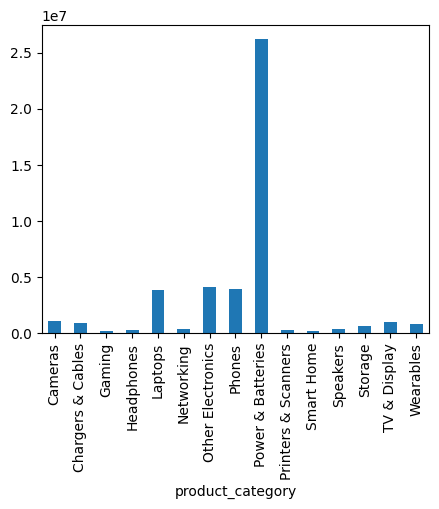

In [ ]:
df.groupby('product_category')['purchased_last_month'].sum().plot(kind = 'bar', figsize = (5,4))
plt.show()

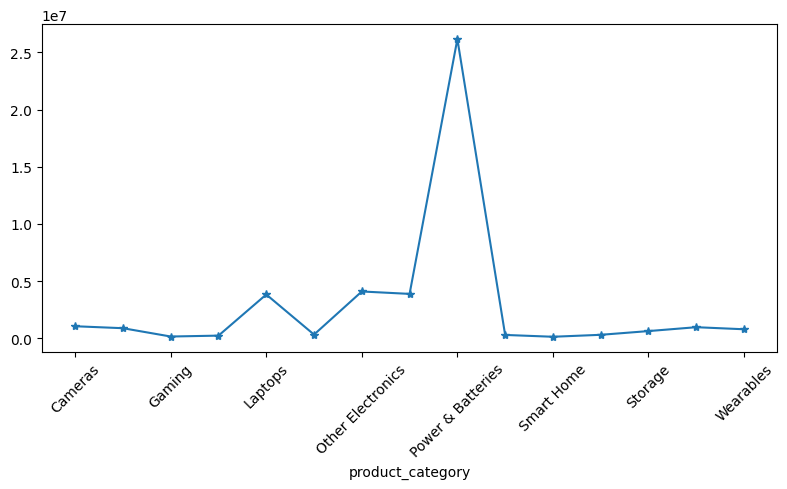

In [61]:
df.groupby('product_category')['purchased_last_month'] \
  .sum() \
  .plot(kind='line', marker='*', figsize=(8,5))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

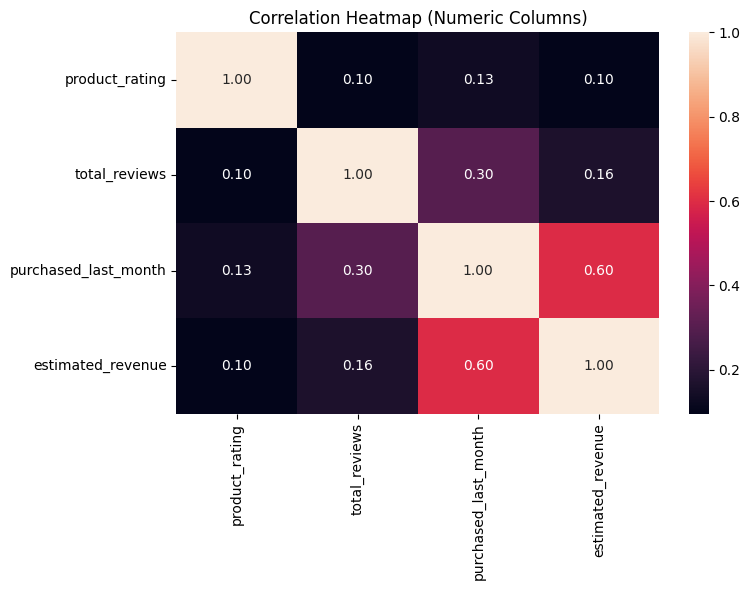

In [ ]:
num_cols = ["product_rating", "total_reviews","purchased_last_month", "estimated_revenue"]
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

**Categorical vs Categorical - crosstab**

In [ ]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discounted_amount', 'estimated_revenue', 'percentage_band'],
      dtype='object')

In [ ]:
df[['product_category', 'is_sponsored']].head()

,product_category,is_sponsored
0,Phones,Sponsored
1,Laptops,Sponsored
2,Laptops,Sponsored
3,Phones,Organic
4,Phones,Organic


In [ ]:
pd.crosstab(index = df["is_sponsored"], columns = df["product_category"])

product_category,Cameras,Chargers & Cables,Gaming,Headphones,Laptops,Networking,Other Electronics,Phones,Power & Batteries,Printers & Scanners,Smart Home,Speakers,Storage,TV & Display,Wearables
is_sponsored,,,,,,,,,,,,,,,
Organic,3109,1573,797,798,8061,837,8568,5190,1339,877,456,1119,1097,1407,436
Sponsored,568,260,12,199,632,233,187,1373,1538,0,9,226,533,1223,18


**Numerical vs Numerical - correlation**

In [ ]:
df[['product_rating', 'purchased_last_month']].head()

,product_rating,purchased_last_month
0,4.6,300
1,4.3,6000
2,4.6,2000
3,4.6,10000
4,4.8,10000


In [ ]:
df[['product_rating', 'purchased_last_month']].corr()

,product_rating,purchased_last_month
product_rating,1.000000,0.134106
purchased_last_month,0.134106,1.000000


## Multi-Variate Analysis

In [ ]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discounted_amount', 'estimated_revenue', 'percentage_band'],
      dtype='object')

In [ ]:
df[['product_category', 'is_sponsored', 'purchased_last_month']].head(2)

,product_category,is_sponsored,purchased_last_month
0,Phones,Sponsored,300
1,Laptops,Sponsored,6000


## PIVOT TABLE

Index - Categorical column

column - Categorical column

Values - Numerical column

In [ ]:
pd.pivot_table(data = df, index = ["product_category"], columns = ["is_sponsored"], values = ["estimated_revenue", "total_reviews"], aggfunc= "sum")

estimated_revenue              total_reviews           
is_sponsored                  Organic    Sponsored       Organic  Sponsored
product_category                                                           
Cameras                   261752174.5   44565693.0     3907413.0  1529043.0
Chargers & Cables          39525772.0    4089655.5     7123839.0   200613.0
Gaming                     15293559.0     709576.0     4424329.0   287493.0
Headphones                 17599338.0    2569606.5     5740934.0    25557.0
Laptops                   727694060.5   46097957.5    14774007.0  3179903.0
Networking                 28315927.5   18404520.0     1393846.0   395332.0
Other Electronics         248622944.5   11827323.5    19107184.0   142605.0
Phones                    220459253.0  119218216.0    20008935.0  9077692.0
Power & Batteries          53966770.5  499987452.0    11764000.0  9050002.0
Printers & Scanners        24330567.0          NaN     1399794.0        NaN
Smart Home                 30452953.5     493984.0     1726532.0      268.0
Speakers                   38590981.5    8086255.0     1375019.0    12296.0
Storage                    41389655.5   24563237.0     5284733.0  1396865.0
TV & Display               75476223.0   36426505.0     3709262.0   819392.0
Wearables                  14089644.5    6738600.0      661295.0   414101.0